In [86]:
#libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

In [87]:
# Loading dataset

df = pd.read_csv("diabetes1.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [88]:
# Dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [89]:
# Checking missing values

print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


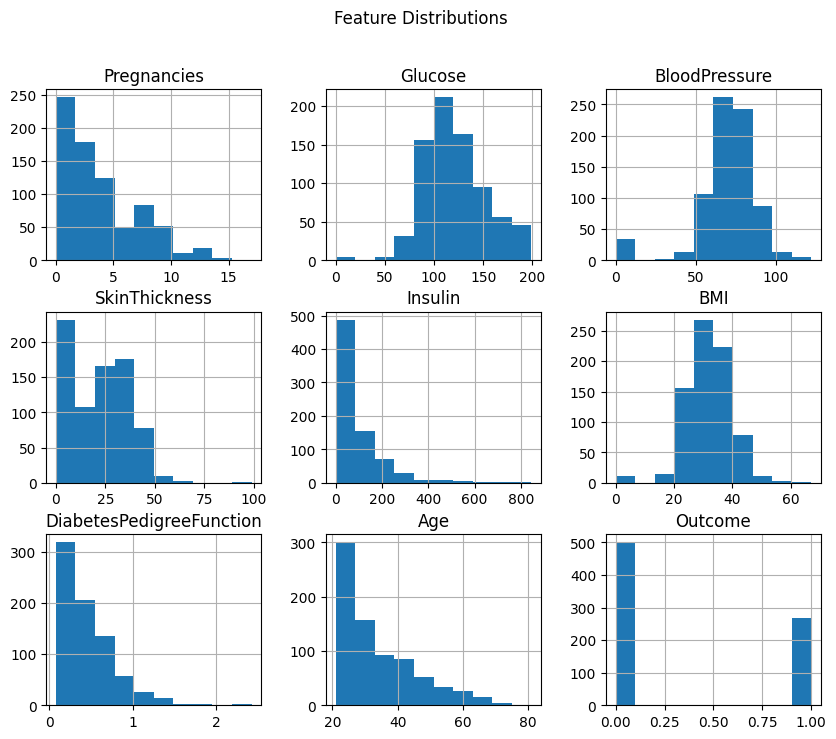

In [90]:
# Histograms

df.hist(figsize=(10,8))
plt.suptitle("Feature Distributions")
plt.show()

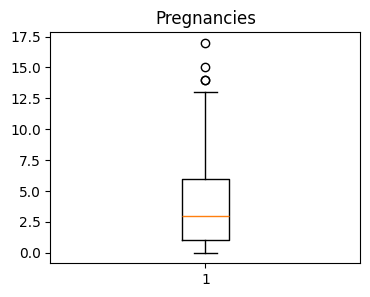

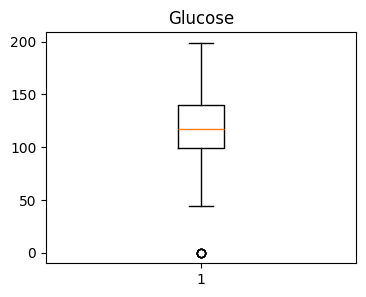

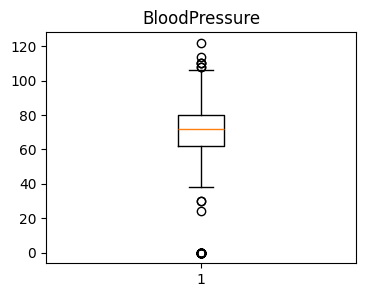

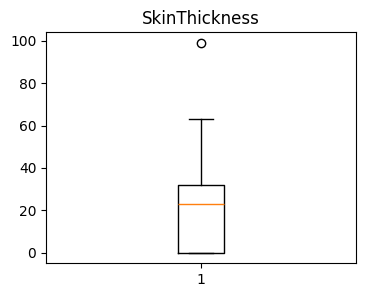

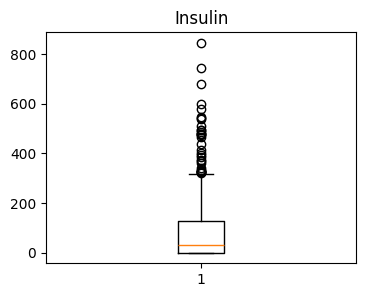

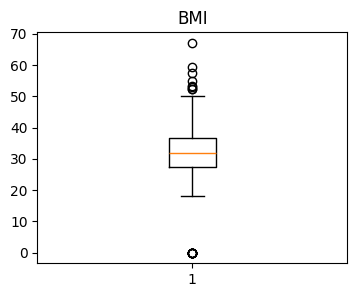

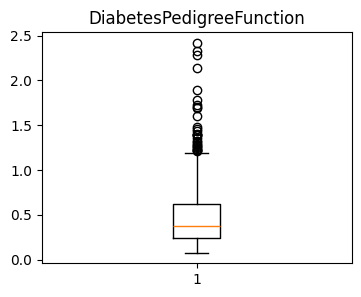

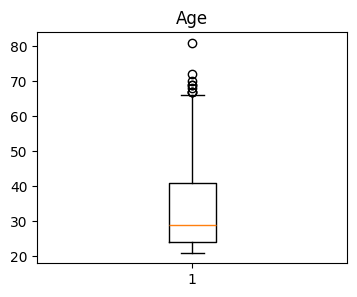

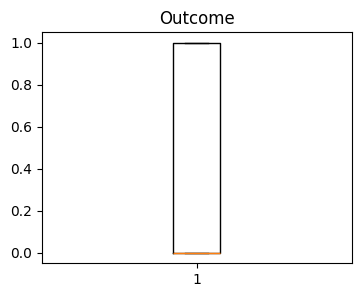

In [91]:
# Boxplots

for col in df.columns:

    plt.figure(figsize=(4,3))

    plt.boxplot(df[col])

    plt.title(col)

    plt.show()

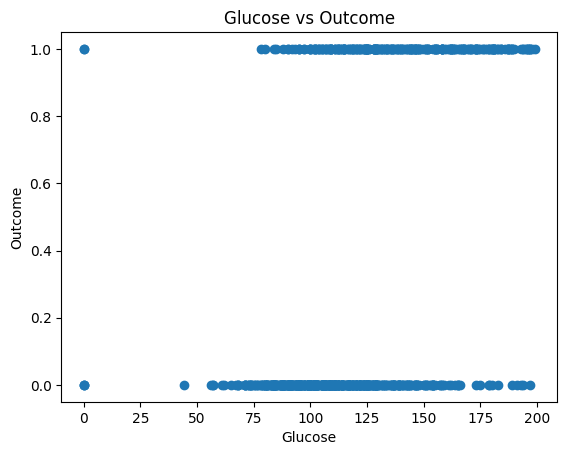

In [92]:
# Scatter plot

plt.scatter(df["Glucose"], df["Outcome"])

plt.xlabel("Glucose")
plt.ylabel("Outcome")
plt.title("Glucose vs Outcome")

plt.show()

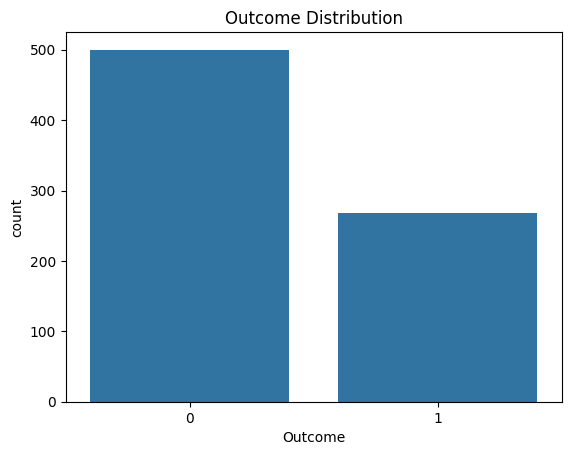

In [93]:
# Bar plot

sns.countplot(x="Outcome", data=df)

plt.title("Outcome Distribution")

plt.show()

In [94]:
# Features and target

X = df.drop("Outcome", axis=1)

y = df["Outcome"]

In [95]:
# Feature scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

The dataset did not contain any missing values, so imputation was not required.

The dataset did not contain categorical variables, so encoding was not required.

Feature scaling was applied using StandardScaler to bring features to a similar scale.

In [96]:
# Train test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [97]:
# LightGBM model

from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    random_state=42,
    verbose=-1
)

lgbm.fit(X_train, y_train)

lgbm_pred = lgbm.predict(X_test)

In [98]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

lgbm_accuracy = accuracy_score(y_test, lgbm_pred)

lgbm_precision = precision_score(y_test, lgbm_pred)

lgbm_recall = recall_score(y_test, lgbm_pred)

lgbm_f1 = f1_score(y_test, lgbm_pred)

print("Accuracy :", lgbm_accuracy)
print("Precision :", lgbm_precision)
print("Recall :", lgbm_recall)
print("F1 Score :", lgbm_f1)

Accuracy : 0.7012987012987013
Precision : 0.5714285714285714
Recall : 0.6545454545454545
F1 Score : 0.6101694915254238


In [99]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    verbosity=0
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

In [100]:
xgb_accuracy = accuracy_score(y_test, xgb_pred)

xgb_precision = precision_score(y_test, xgb_pred)

xgb_recall = recall_score(y_test, xgb_pred)

xgb_f1 = f1_score(y_test, xgb_pred)

print("Accuracy :", xgb_accuracy)
print("Precision :", xgb_precision)
print("Recall :", xgb_recall)
print("F1 Score :", xgb_f1)

Accuracy : 0.7207792207792207
Precision : 0.5909090909090909
Recall : 0.7090909090909091
F1 Score : 0.6446280991735537


In [101]:
#lgbm crossvalidation
from sklearn.model_selection import cross_val_score

lgbm_scores = cross_val_score(
    lgbm,
    X_scaled,
    y,
    cv=5
)

lgbm_cv = lgbm_scores.mean()

print(lgbm_scores)

print("Mean CV Score :", lgbm_cv)

[0.71428571 0.75324675 0.74675325 0.76470588 0.71895425]
Mean CV Score : 0.7395891690009337


In [102]:
#xgb crossvalidation
xgb_scores = cross_val_score(
    xgb,
    X_scaled,
    y,
    cv=5
)

xgb_cv = xgb_scores.mean()

print(xgb_scores)

print("Mean CV Score :", xgb_cv)

[0.72077922 0.72727273 0.72077922 0.81699346 0.71895425]
Mean CV Score : 0.7409557762498938


In [103]:
#lgbm hyperparameter tuning
from lightgbm import LGBMClassifier

lgbm_tuned = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    verbose=-1
)

lgbm_tuned.fit(X_train, y_train)

lgbm_tuned_pred = lgbm_tuned.predict(X_test)

lgbm_tuned_accuracy = accuracy_score(
    y_test,
    lgbm_tuned_pred
)

print("Tuned Accuracy :",
      lgbm_tuned_accuracy)

Tuned Accuracy : 0.7272727272727273


In [104]:
#xgb hyperparameter tuning
from xgboost import XGBClassifier

xgb_tuned = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    eval_metric="logloss",
    verbosity=0
)

xgb_tuned.fit(X_train, y_train)

xgb_tuned_pred = xgb_tuned.predict(X_test)

xgb_tuned_accuracy = accuracy_score(
    y_test,
    xgb_tuned_pred
)

print("Tuned Accuracy :",
      xgb_tuned_accuracy)

Tuned Accuracy : 0.7077922077922078


In [105]:
#final comparision

print("LightGBM Accuracy :", lgbm_accuracy)

print("XGBoost Accuracy :", xgb_accuracy)

print("LightGBM CV Score :", lgbm_cv)

print("XGBoost CV Score :", xgb_cv)

print("LightGBM Tuned Accuracy :",
      lgbm_tuned_accuracy)

print("XGBoost Tuned Accuracy :",
      xgb_tuned_accuracy)

LightGBM Accuracy : 0.7012987012987013
XGBoost Accuracy : 0.7207792207792207
LightGBM CV Score : 0.7395891690009337
XGBoost CV Score : 0.7409557762498938
LightGBM Tuned Accuracy : 0.7272727272727273
XGBoost Tuned Accuracy : 0.7077922077922078


**Comparative** **Analysis** \

The performance of LightGBM and XGBoost was compared using Accuracy, Precision, Recall, F1 Score, and Cross Validation.

LightGBM Accuracy = 0.7013

XGBoost Accuracy = 0.7208

LightGBM Cross Validation Score = 0.7396

XGBoost Cross Validation Score = 0.7410

After hyperparameter tuning:

LightGBM Tuned Accuracy = 0.7273   
     
XGBoost Tuned Accuracy = 0.7078

Based on the evaluation results, XGBoost achieved slightly higher accuracy before tuning. However, after hyperparameter tuning, LightGBM achieved the best accuracy among the models.

**Strengths and Weaknesses**

LightGBM Strengths:
• Faster training speed.

• Efficient memory usage.

• Performs well on large datasets.

LightGBM Weaknesses:

• Can be sensitive to parameter settings.

XGBoost Strengths:

• High predictive performance.

• Effective regularization helps reduce overfitting.

XGBoost Weaknesses:

• Higher computational cost.

• Training can be slower than LightGBM.

**Practical Implications**

Both LightGBM and XGBoost can be used for diabetes prediction.

These models help identify individuals who are at risk of diabetes based on medical attributes.

Such predictions can support early diagnosis and assist healthcare professionals in making informed decisions.